In [1]:
import os
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras

from tensorflow.keras import layers, models


2025-09-17 07:06:25.742698: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-17 07:06:25.742776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-17 07:06:25.743971: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-17 07:06:25.751497: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-17 07:06:32.944963: W tensorflow/compiler/tf2

In [4]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer

pi = 3.14159265359

maxval=1e9
minval=1e-9

In [5]:
# Trasformer model

class PatchExtractor(layers.Layer):
  """Extract 2D patches from images."""
  def __init__(self, patch_size=(3,7)):
    super().__init__()
    self.patch_size = patch_size

  def call(self, images):
    # images: (batch, H, W, C)
    patch_h, patch_w = self.patch_size
    batch_size = tf.shape(images)[0]
    patches = tf.image.extract_patches(
        images=images,
        sizes=(1, patch_h, patch_w, 1),
        strides=(1, patch_h, patch_w, 1),
        rates=(1,1,1,1),
        padding='VALID'
    )
    # Now `patches` has shape: 
    #   (batch, H//patch_h, W//patch_w, patch_h*patch_w*C)
    # Flatten the 2D grid of patches => (batch, num_patches, patch_dim)
    patch_dims = tf.shape(patches)[-1]
    patches = tf.reshape(
        patches,
        [batch_size, -1, patch_dims]
    )
    return patches

class PatchEncoder(layers.Layer):
  """Linear embedding + learnable positional encoding."""
  def __init__(self, num_patches, embed_dim):
    super().__init__()
    self.num_patches = num_patches
    self.projection  = layers.Dense(embed_dim)
    self.pos_embed   = tf.Variable(
        initial_value=tf.zeros((1,num_patches,embed_dim)),
        trainable=True,
        name="pos_embedding"
    )

  def call(self, patch_batch):
    # Linear projection of patch tokens
    projected = self.projection(patch_batch)
    # Add learnable positional embeddings
    return projected + self.pos_embed

def transformer_encoder(inputs,
                        head_size,
                        num_heads,
                        ff_dim,
                        dropout=0.1):
  # LayerNorm + Multi-head attention
  x = layers.LayerNormalization(epsilon=1e-6)(inputs)
  x = layers.MultiHeadAttention(num_heads=num_heads,
                                key_dim=head_size,
                                dropout=dropout)(x, x)
  x = layers.Dropout(dropout)(x)
  res = x + inputs
  
  # Next LN + feed-forward
  x = layers.LayerNormalization(epsilon=1e-6)(res)
  x = layers.Dense(ff_dim, activation="relu")(x)
  x = layers.Dropout(dropout)(x)
  x = layers.Dense(inputs.shape[-1], activation="linear")(x)
  x = layers.Dropout(dropout)(x)
  
  return x + res

def create_vit_model(input_shape=(13,21,2),
                     patch_size=(3,7),
                     embed_dim=64,
                     num_heads=4,
                     ff_dim=128,
                     num_layers=4,
                     dropout=0.1,
                     final_outputs=14):
  # Input
  inp = layers.Input(shape=input_shape, name="raw_input")

  q_out = SoftQuantizeLayer(
      n_bits=2,
      initial_range=[-1.0, 1.0],
      trainable_levels=False,
      trainable_thresholds=True,
      initial_k=1.0,
      trainable_k=True,
      name="soft_quantizer_output"
  )(inp)

  # 1) Extract patches
  patches = PatchExtractor(patch_size=patch_size)(q_out)
  
  # Calculate how many patches we extracted:
  #   (H // patch_h) * (W // patch_w)
  # Must do it statically if possible:
  # e.g. 13//3=4, 21//7=3 => 12 patches total
  H, W, C = input_shape
  ph, pw  = patch_size
  num_patches = (H // ph) * (W // pw)

  # 2) Encode patches (linear projection + positional embedding)
  encoded_patches = PatchEncoder(num_patches, embed_dim)(patches)

  # 3) Apply multiple Transformer encoder blocks
  x = encoded_patches
  for _ in range(num_layers):
    x = transformer_encoder(x,
                            head_size=embed_dim,
                            num_heads=num_heads,
                            ff_dim=ff_dim,
                            dropout=dropout)
  
  # 4) Flatten and final Dense
  x = layers.LayerNormalization(epsilon=1e-6)(x)
  x = layers.Flatten()(x)
  x = layers.Dense(64, activation='relu')(x)
  outputs = layers.Dense(final_outputs, activation='linear')(x)

  # Create model
  model = keras.Model(inputs=inp, outputs=outputs)
  return model

model = create_vit_model(
    input_shape=(16,16,2),   
    patch_size=(3,4),        
    embed_dim=64,           
    num_heads=4,            
    ff_dim=128,              
    num_layers=4,            
    dropout=0.1,             
    final_outputs=14         
)

2025-09-17 07:08:11.270399: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 857 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB MIG 7g.40gb, pci bus id: 0000:21:00.0, compute capability: 8.0
2025-09-17 07:08:11.533215: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


In [6]:
def extract_val_metric(fname):
    try:
        val_str = fname.split("-v-")[-1].replace(".hdf5", "")
        return float(val_str)
    except Exception:
        return float("-inf")



In [7]:
def map_normalized_to_raw_charge(model, data_generator):
    """Map soft quantization thresholds & levels from normalized to raw charge space"""
    
    # Extract soft quantization parameters
    sq_layer = model.get_layer(name="soft_quantizer_output")
    thresholds = sq_layer.thresholds.numpy()
    
    # Get normalization parameters from data generator
    mu, sigma = data_generator.dataset_mean[0], data_generator.dataset_std[0] 
    s_pos, s_neg = data_generator.norm_factor_pos, data_generator.norm_factor_neg
    
    def reverse_transform(norm_vals):
        """Reverse the full normalization pipeline"""
        # Step 1: Reverse asymmetric scaling
        scaled_back = np.where(norm_vals > 0, norm_vals * s_pos, norm_vals * s_neg)
        
        # Step 2: Reverse standardization  
        log_vals = scaled_back * sigma + mu
        
        # Step 3: Reverse log compression: x_raw = sign(x_log) * (2^|x_log| - 1)
        raw_charges = np.sign(log_vals) * (2**np.abs(log_vals) - 1)
        
        return raw_charges
    
    # Apply reverse transformation
    raw_thresholds = reverse_transform(thresholds)
    return raw_thresholds

In [8]:
dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/"

NOISE_MU = 0.0
NOISE_SIGMA = 400.0 # e-

tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", f"2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")


In [9]:
test_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=True,
)
labels_scale = test_generator.labels_scale
print(labels_scale)

Loading metadata from /depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/TFR_files/2t_N_0.0mu_400.0sig/TFR_val/metadata.json
[99.17029747 24.79370923  6.53245764  1.89031215]


In [10]:
# 258K    Transformer_model-6bc1dfae-checkpoints
# 11M     Transformer_model-f460e105-checkpoints
# 15M     Transformer_model-6671215d-checkpoints
# 838M    Transformer_model-95a1445d-checkpoints
# 3.5G    Transformer_model-5023ece2-checkpoints
# 3.5G    Transformer_model-5606e0d3-checkpoints
# 3.5G    Transformer_model-641e5444-checkpoints
# 3.5G    Transformer_model-a8643d7e-checkpoints
# 3.5G    Transformer_model-f6a93ae5-checkpoints
# [das214@purdue-af-46 trained_models]$ 

In [13]:
import glob

models_base_dir = "/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models"
paths = glob.glob(f"{models_base_dir}/Transformer_model-*-checkpoints")

for p in paths:
    print(p)

/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-5606e0d3-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-a8643d7e-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-f460e105-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-5023ece2-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-f6a93ae5-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-95a1445d-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-641e5444-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-cc6cbe23-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-6671215d-checkpoints
/depot/cms/users/das214/SmartPixels/SoftQuantize/trained_models/Transform

In [21]:
# fingerprint_list = ["5023ece2", "f6a93ae5", "a8643d7e", "641e5444", "5606e0d3"]
fingerprint_list = ["cc6cbe23"]

In [23]:
all_results_df = []

for fingerprint in fingerprint_list:
    base_dir = os.path.join(models_base_dir, f'Transformer_model-{fingerprint}-checkpoints')
    checkpoints_dir = os.path.join(base_dir, 'checkpoints')
    training_log = os.path.join(base_dir, 'training_log.csv')
    quantizer_log = os.path.join(base_dir, 'soft_quantizer_state_log.csv')

    # --- Load logs ---
    training_df = pd.read_csv(training_log)
    quant_df = pd.read_csv(quantizer_log)

    if len(training_df) != len(quant_df):
        raise ValueError(f"[{fingerprint}] Mismatch: training_log has {len(training_df)}, quantizer_log has {len(quant_df)}")

    checkpoint_files = sorted([
        os.path.join(checkpoints_dir, f)
        for f in os.listdir(checkpoints_dir)
        if f.endswith(".hdf5")
    ])

    best_ckpt = max(checkpoint_files, key=lambda f: extract_val_metric(os.path.basename(f)))
    best_val = extract_val_metric(os.path.basename(best_ckpt))

    print(f"[{fingerprint}] Best checkpoint: {os.path.basename(best_ckpt)} (val = {best_val:.4f})")

    # --- Load model + thresholds ---
    model = create_vit_model(
        input_shape=(16, 16, 2),
        patch_size=(3, 4),
        embed_dim=64,
        num_heads=4,
        ff_dim=128,
        num_layers=4,
        dropout=0.1,
        final_outputs=14
    )

    model.load_weights(best_ckpt)

    # raw_thresholds = map_normalized_to_raw_charge(model, test_generator)  # → shape (4,)
    raw_thresholds = map_normalized_to_raw_charge(model, test_generator)  # Assumed to return 1D array
    del model  # cleanup

    # --- Combine logs ---
    df = training_df.copy()
    df["fingerprint"] = fingerprint
    df["best_val_metric"] = best_val
    for i, val in enumerate(raw_thresholds):
        df[f"raw_threshold_{i}"] = val

    # Add soft quantizer internals (assumed to be per-epoch)
    for col in quant_df.columns:
        df[f"quantizer_{col}"] = quant_df[col]

    all_results_df.append(df)

# === Final aggregation ===
final_df = pd.concat(all_results_df, ignore_index=True)

[cc6cbe23] Best checkpoint: weights.880-t-21713.22-v-22401.58.hdf5 (val = 22401.5800)


In [25]:
final_df.keys()

Index(['epoch', 'loss', 'val_loss', 'fingerprint', 'best_val_metric',
       'raw_threshold_0', 'raw_threshold_1', 'raw_threshold_2',
       'quantizer_epoch', 'quantizer_k', 'quantizer_level_0',
       'quantizer_level_1', 'quantizer_level_2', 'quantizer_level_3',
       'quantizer_threshold_0', 'quantizer_threshold_1',
       'quantizer_threshold_2', 'quantizer_raw_first_level',
       'quantizer_raw_log_level_delta_0', 'quantizer_raw_log_level_delta_1',
       'quantizer_raw_log_level_delta_2', 'quantizer_raw_first_threshold',
       'quantizer_raw_log_threshold_delta_0',
       'quantizer_raw_log_threshold_delta_1'],
      dtype='object')

In [17]:
thresholds_list = np.array(thresholds_list)
print(thresholds_list)

[[ 618.7343 1116.9932 2058.5562]]


In [45]:
def unnormalize_thresholds(norm_thresh, mu, sigma, s_pos, s_neg):
    norm_thresh = np.asarray(norm_thresh)
    scaled_back = np.where(norm_thresh > 0, norm_thresh * s_pos, norm_thresh * s_neg)
    log_vals = scaled_back * sigma + mu
    raw_charges = np.sign(log_vals) * (2 ** np.abs(log_vals) - 1)

    return raw_charges

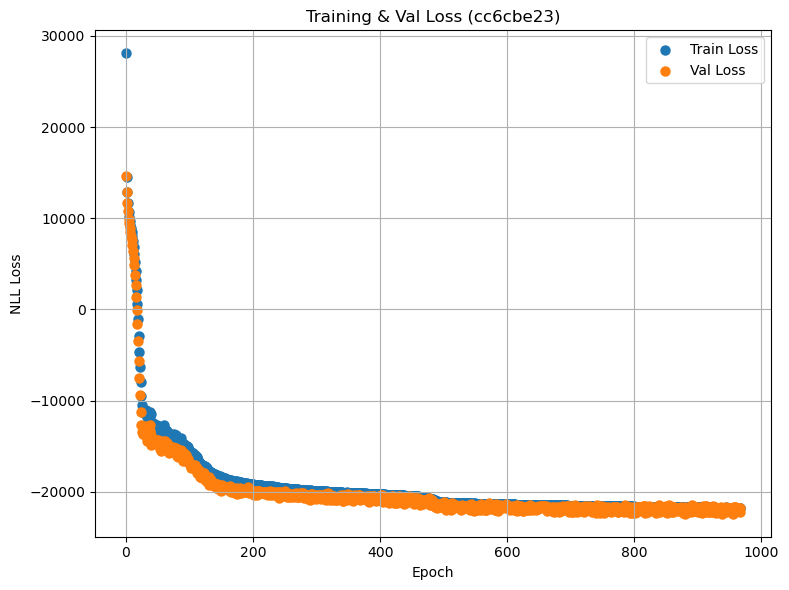

In [57]:
norm_th0, norm_th1, norm_th2 = [], [], []
raw_th0, raw_th1, raw_th2 = [], [], []

# === Collect from each fingerprint ===
for fingerprint in fingerprint_list:
    df = final_df[final_df['fingerprint'] == fingerprint].sort_values("epoch")
    last = df.iloc[-1]

    # Normalized thresholds
    t0 = last['quantizer_threshold_0']
    t1 = last['quantizer_threshold_1']
    t2 = last['quantizer_threshold_2']
    norm_vec = [t0, t1, t2]

    # Map to raw charge space
    charge_vec = unnormalize_thresholds(norm_vec,
        mu=test_generator.dataset_mean[0],
        sigma=test_generator.dataset_std[0],
        s_pos=test_generator.norm_factor_pos,
        s_neg=test_generator.norm_factor_neg
    )

    # Append
    norm_th0.append(t0)
    norm_th1.append(t1)
    norm_th2.append(t2)
    raw_th0.append(charge_vec[0])
    raw_th1.append(charge_vec[1])
    raw_th2.append(charge_vec[2])

    # Optional loss plot
    plt.figure(figsize=(8,6))
    plt.scatter(df['epoch'], df['loss'], label='Train Loss', lw=1.5)
    plt.scatter(df['epoch'], df['val_loss'], label='Val Loss', lw=1.5)
    plt.title(f"Training & Val Loss ({fingerprint})")
    plt.xlabel("Epoch")
    plt.ylabel("NLL Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

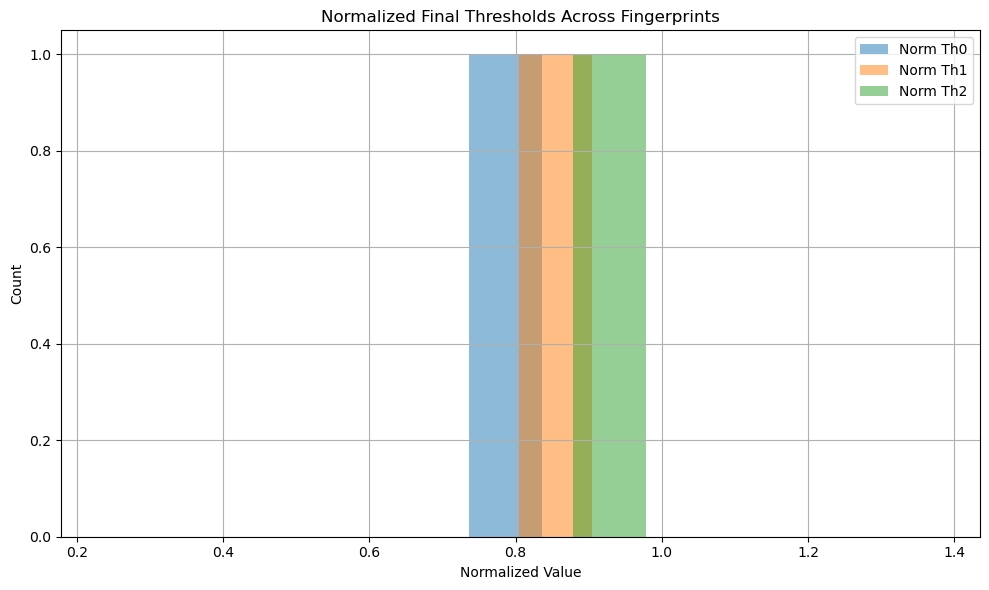

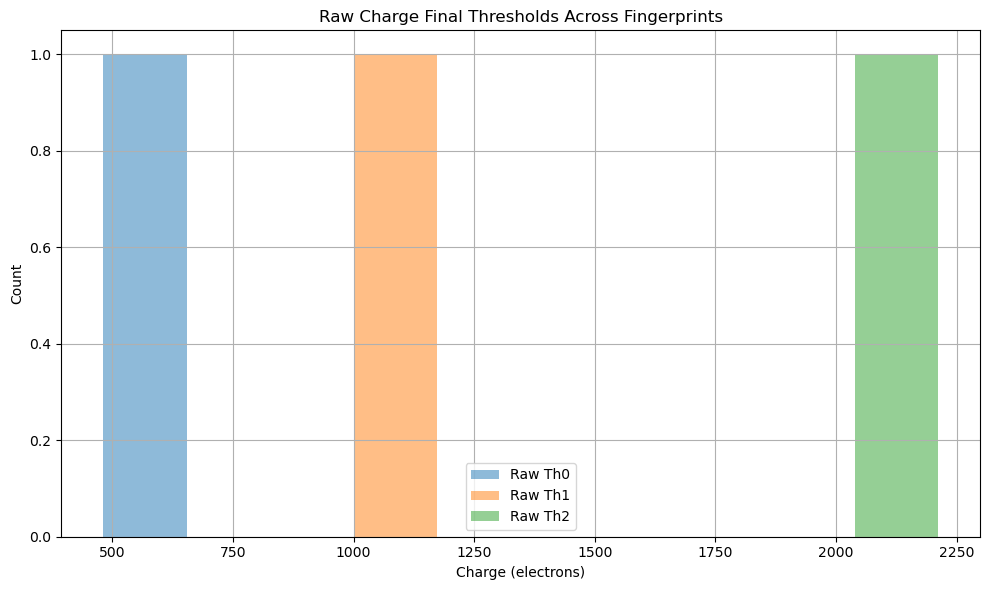

In [58]:
# === Plot: Normalized thresholds ===
plt.figure(figsize=(10, 6))
plt.hist(norm_th0, bins=10, alpha=0.5, label="Norm Th0")
plt.hist(norm_th1, bins=10, alpha=0.5, label="Norm Th1")
plt.hist(norm_th2, bins=10, alpha=0.5, label="Norm Th2")
plt.title("Normalized Final Thresholds Across Fingerprints")
plt.xlabel("Normalized Value")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Plot: Raw charge-space thresholds ===
all_raw = raw_th0 + raw_th1 + raw_th2
min_v, max_v = min(all_raw), max(all_raw)

# Add 10% margin around full range
pad = 0.1 * (max_v - min_v)
range_min = min_v - pad
range_max = max_v + pad

plt.figure(figsize=(10, 6))
plt.hist(raw_th0, bins=10, range=(range_min, range_max), alpha=0.5, label="Raw Th0")
plt.hist(raw_th1, bins=10, range=(range_min, range_max), alpha=0.5, label="Raw Th1")
plt.hist(raw_th2, bins=10, range=(range_min, range_max), alpha=0.5, label="Raw Th2")
plt.title("Raw Charge Final Thresholds Across Fingerprints")
plt.xlabel("Charge (electrons)")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()